<a href="https://colab.research.google.com/github/RaihanDaffa04/PCVK_Ganjil2026/blob/main/Week03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 30


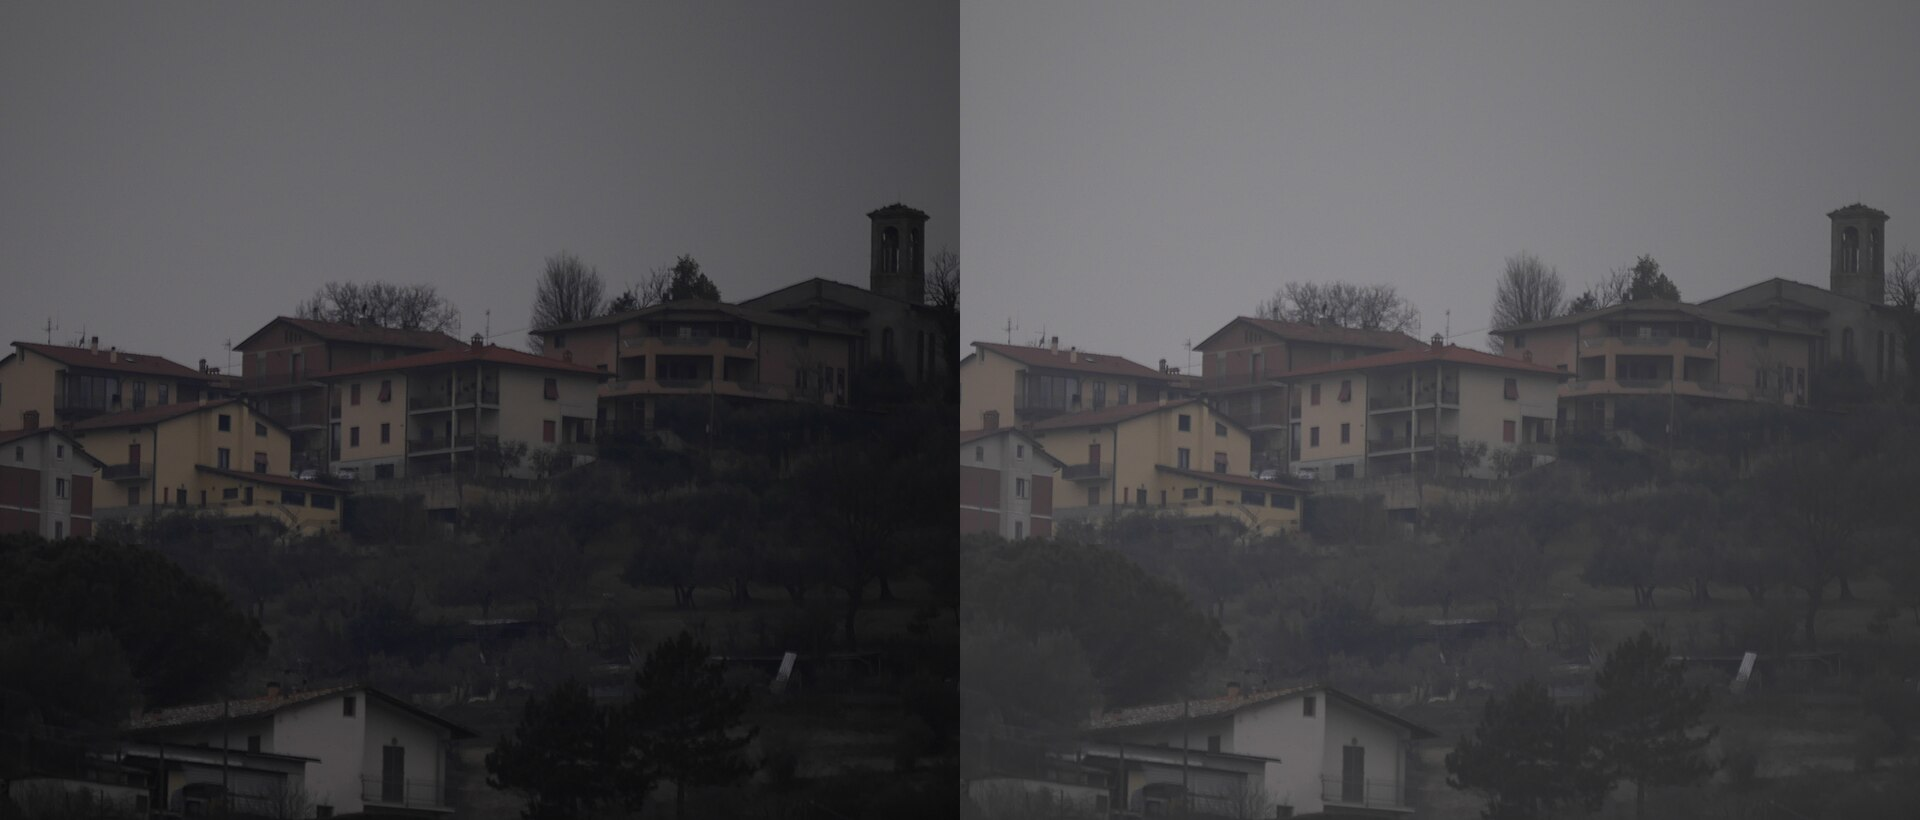

In [49]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Images/houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

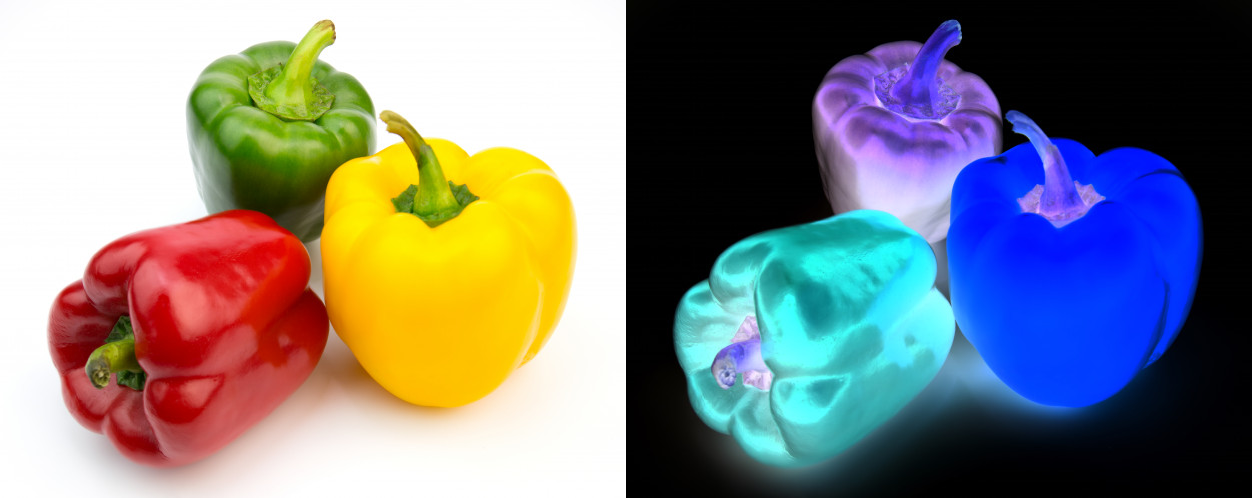

In [50]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

original_1 = cv.imread('/content/drive/MyDrive/PCVK/Images/peppers.jpg')

inverse_image = 255 - original_1

final_frame_1 = cv.hconcat((original_1, inverse_image))
cv2_imshow(final_frame_1)

Mengubah kontras dan tingkat kecerahan citra
--------------------------------------------
Masukkan tingkat kecerahan : 10
Masukkan kontras : 1.5


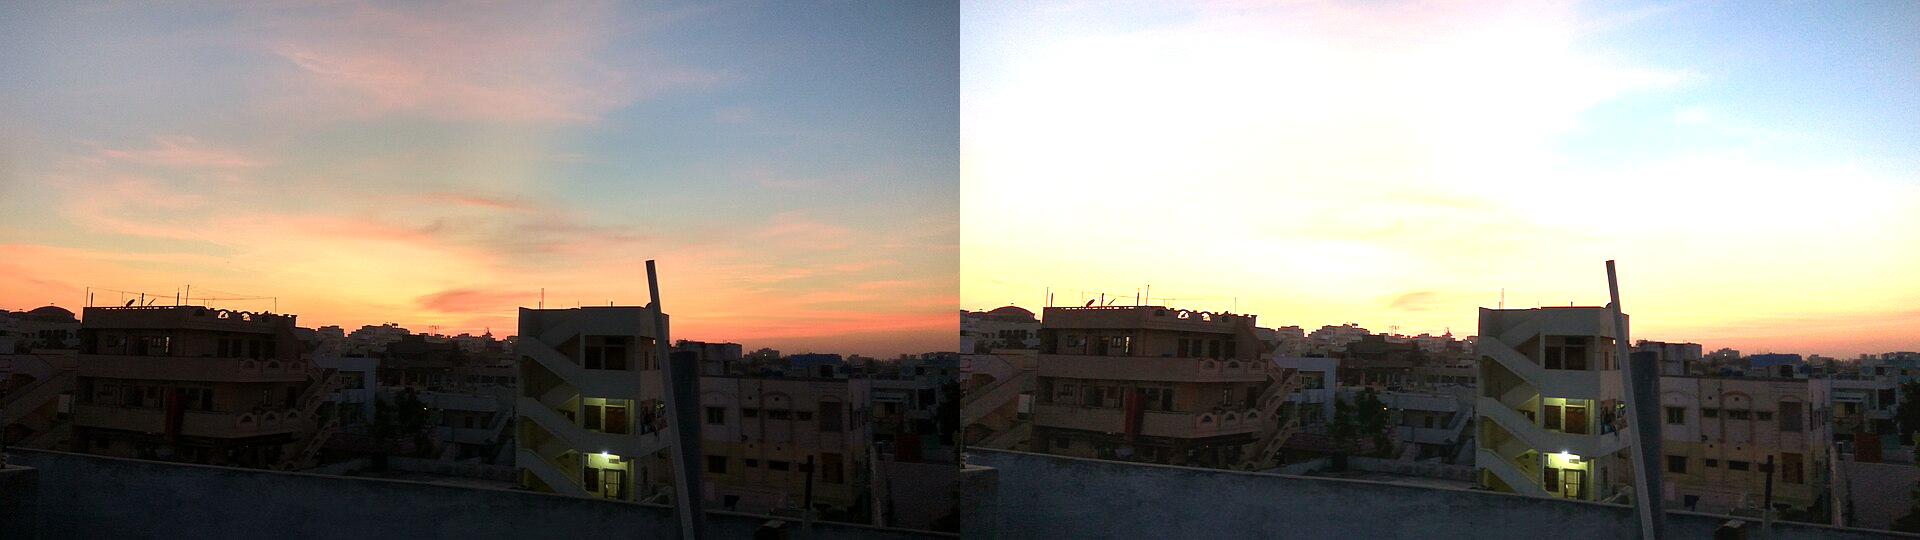

In [52]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('--------------------------------------------')
try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, pastikan memasukkan angka')

original_2 = cv.imread('/content/drive/MyDrive/PCVK/Images/sunset.jpg')
contrast_image = np.zeros(original_2.shape, original_2.dtype)

for y in range(original_2.shape[0]):
    for x in range(original_2.shape[1]):
        for c in range(original_2.shape[2]):
            contrast_image[y,x,c] = np.clip(contrast * original_2[y,x,c] + brightness, 0, 255)

final_frame_2 = cv.hconcat((original_2, contrast_image))
cv2_imshow(final_frame_2)

Mengubah tingkat kecerahan citra dengan Transformasi Log
--------------------------------------------------------
Masukkan nilai kecerahan: 50


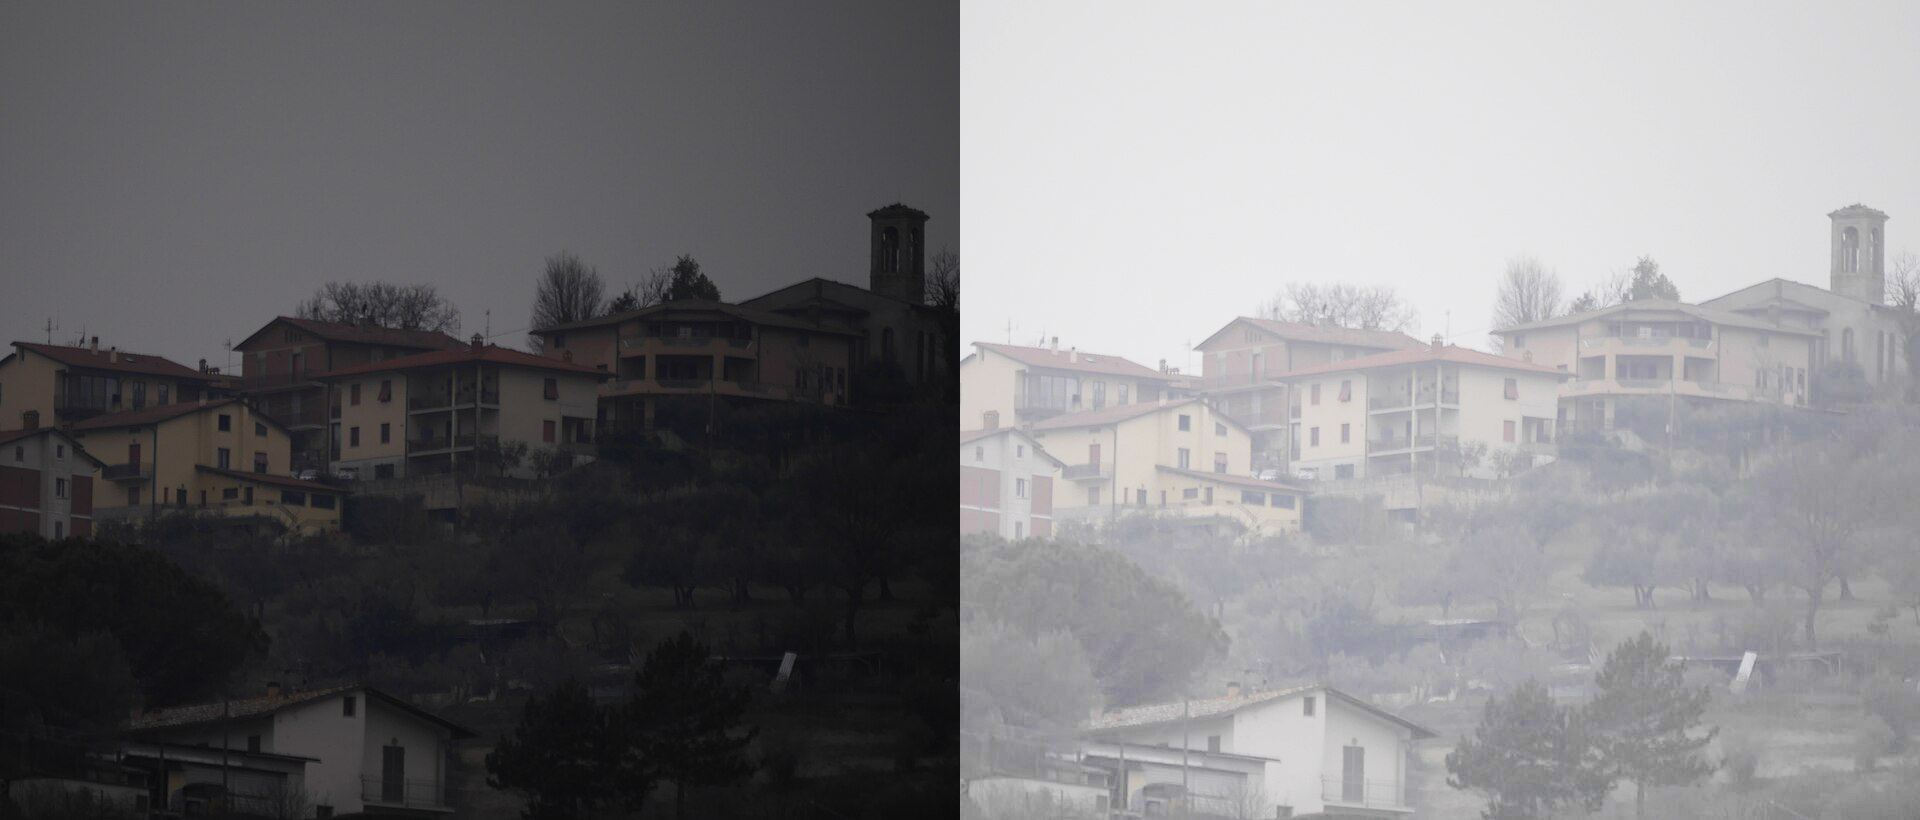

In [53]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('--------------------------------------------------------')
try:
    c = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, pastikan memasukkan angka')

original_3 = cv.imread('/content/drive/MyDrive/PCVK/Images/houses.jpg')
log_image = c * (np.log(1 + original_3.astype(np.float64)))
log_image = np.clip(log_image, 0, 255).astype(np.uint8)

final_frame_3 = cv.hconcat((original_3, log_image))
cv2_imshow(final_frame_3)

a. Averaging


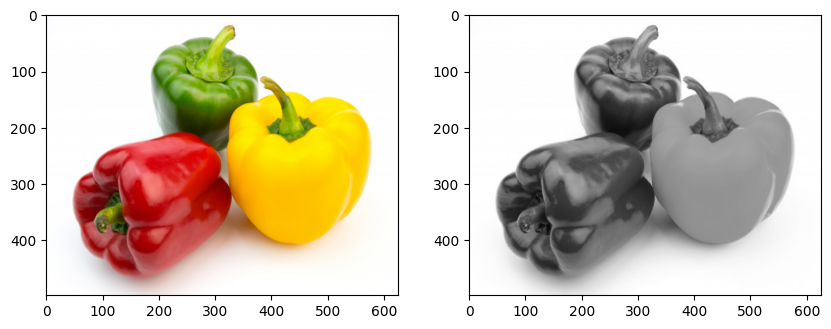

b. Lightness


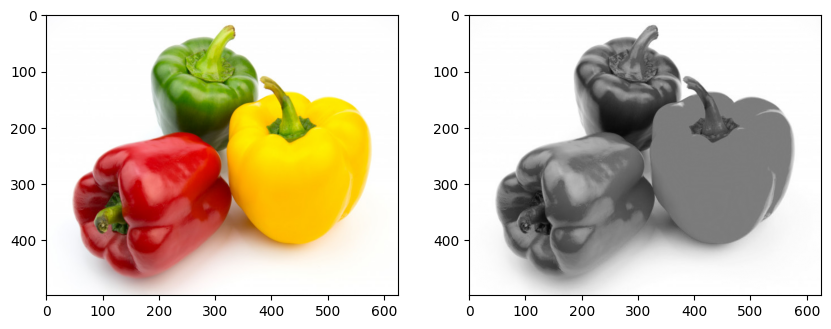

c. Luminance


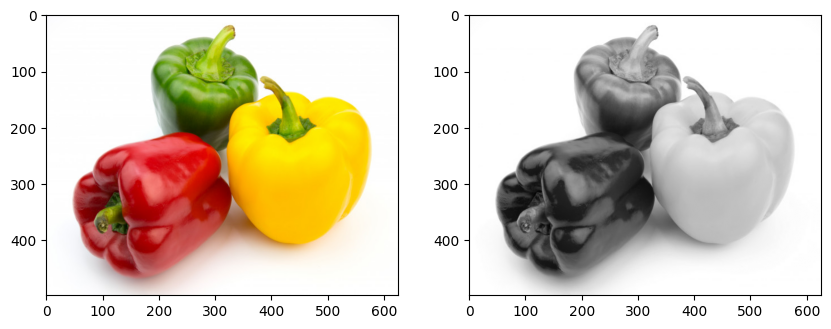

In [54]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/PCVK/Images/peppers.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

R = img_rgb[:,:,0].astype(np.float64)
G = img_rgb[:,:,1].astype(np.float64)
B = img_rgb[:,:,2].astype(np.float64)

gray_avg = (R + G + B) / 3.0
gray_avg = np.clip(gray_avg, 0, 255).astype(np.uint8)

gray_lightness = (np.maximum.reduce([R, G, B]) + np.minimum.reduce([R, G, B])) / 2.0
gray_lightness = np.clip(gray_lightness, 0, 255).astype(np.uint8)

gray_luminance = (0.21 * R) + (0.72 * G) + (0.07 * B)
gray_luminance = np.clip(gray_luminance, 0, 255).astype(np.uint8)

print("a. Averaging")
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img_rgb)
ax[1].imshow(gray_avg, cmap='gray')
plt.show()

print("b. Lightness")
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img_rgb)
ax[1].imshow(gray_lightness, cmap='gray')
plt.show()

print("c. Luminance")
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img_rgb)
ax[1].imshow(gray_luminance, cmap='gray')
plt.show()

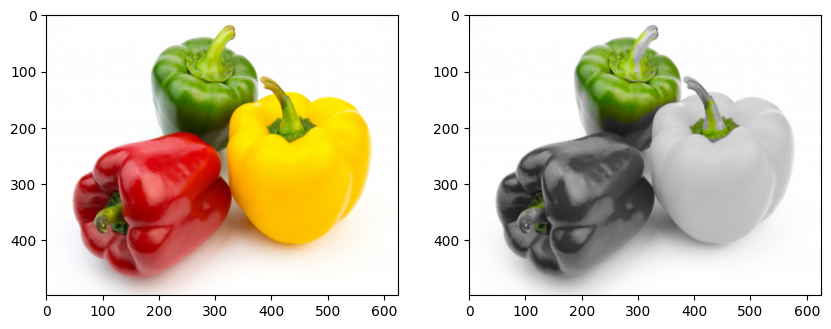

In [55]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/PCVK/Images/peppers.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

img_hsv = cv.cvtColor(img_rgb, cv.COLOR_RGB2HSV)
lower_green = np.array([35, 50, 50])
upper_green = np.array([85, 255, 255])

mask = cv.inRange(img_hsv, lower_green, upper_green)

gray = cv.cvtColor(img_rgb, cv.COLOR_RGB2GRAY)
gray_3ch = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

result = np.where(mask[:, :, None] > 0, img_rgb, gray_3ch)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img_rgb)
ax[1].imshow(result)
plt.show()

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 0.5


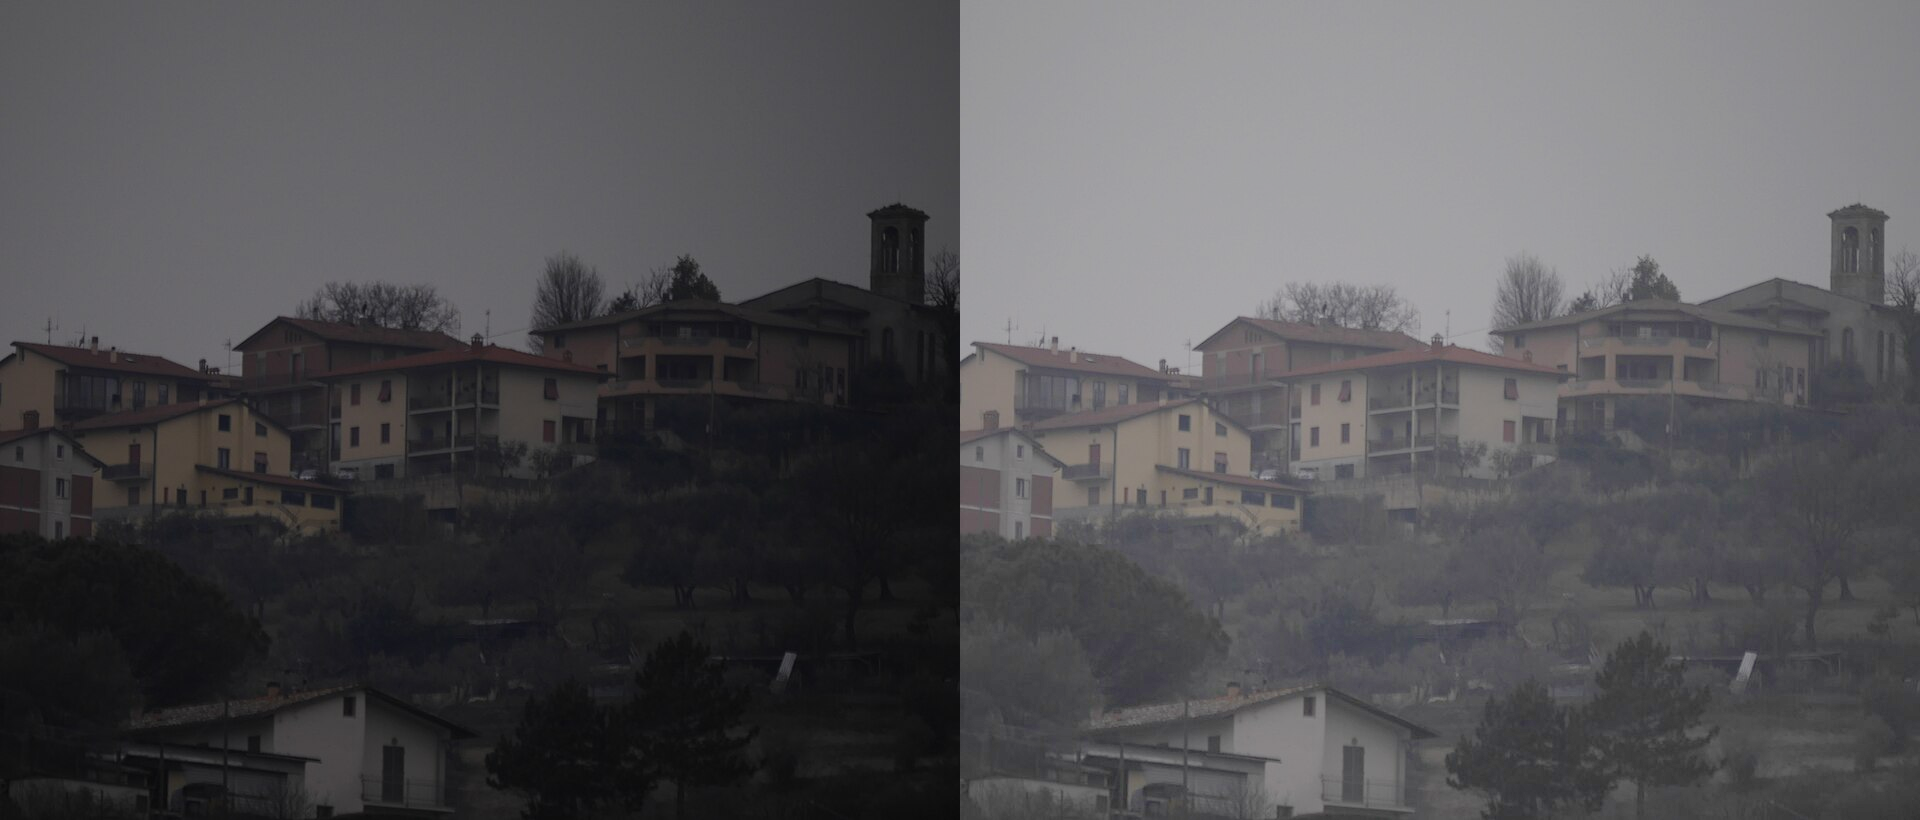

In [56]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Images/houses.jpg')

gamma_image = 255.0 * (original / 255.0) ** gamma
gamma_image = np.clip(gamma_image, 0, 255).astype(np.uint8)

final_frame = cv.hconcat((original, gamma_image))
cv2_imshow(final_frame)

Masukkan bit depth tujuan (1-8): 3
Bit depth awal  : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8


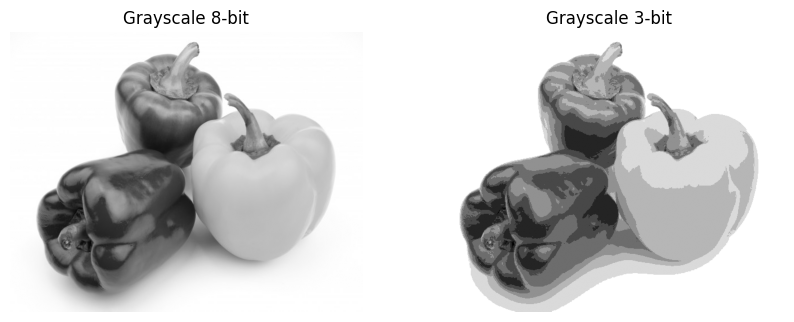

In [57]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))

level = 255.0 / (pow(2, bit_depth) - 1)
jumlah_level = pow(2, bit_depth)

print('Bit depth awal  : 8 bit')
print(f'Bit depth tujuan: {bit_depth} bit')
print(f'Jumlah level    : {jumlah_level}')

original = cv.imread('/content/drive/MyDrive/PCVK/Images/peppers.jpg', cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original.shape, original.dtype)

depth_image = np.round(original / level) * level
depth_image = depth_image.astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(original, cmap='gray')
ax[0].set_title('Grayscale 8-bit')
ax[0].axis('off')

ax[1].imshow(depth_image, cmap='gray')
ax[1].set_title(f'Grayscale {bit_depth}-bit')
ax[1].axis('off')

plt.show()

Jumlah Citra di Average: 10
Nilai PSNR: 19.73 dB


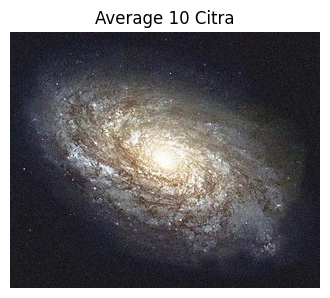

----------------------------------------
Jumlah Citra di Average: 20
Nilai PSNR: 19.83 dB


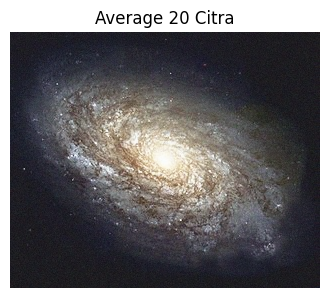

----------------------------------------
Jumlah Citra di Average: 40
Nilai PSNR: 19.89 dB


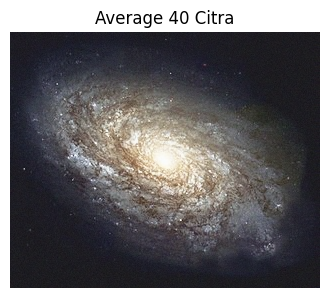

----------------------------------------
Jumlah Citra di Average: 80
Nilai PSNR: 19.92 dB


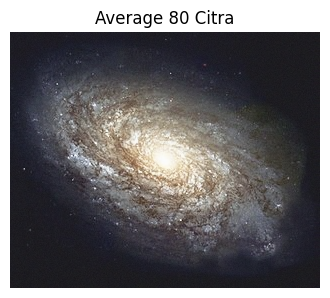

----------------------------------------
Jumlah Citra di Average: 100
Nilai PSNR: 19.92 dB


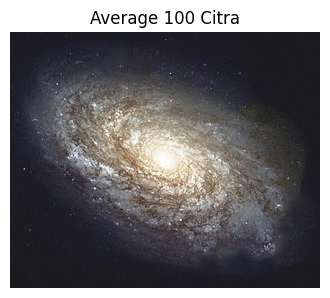

----------------------------------------


In [58]:
import cv2 as cv
import numpy as np
import glob
import math
import matplotlib.pyplot as plt

def PSNR(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if (mse == 0):
        return 100
    max_pixel = 255.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr

citra_asli = cv.imread('/content/drive/MyDrive/PCVK/Images/galaxy.jpg')

cv_img = []
for img in glob.glob('/content/drive/MyDrive/PCVK/Images/noises/*.jpg'):
    n = cv.imread(img)
    cv_img.append(n)

jumlah_citra = [10, 20, 40, 80, 100]

for jml in jumlah_citra:
    img_avg = np.zeros_like(citra_asli, dtype=np.float64)
    for i in range(jml):
        img_avg += cv_img[i]

    img_avg = img_avg / jml
    img_avg = np.clip(img_avg, 0, 255).astype(np.uint8)

    nilai_psnr = PSNR(citra_asli, img_avg)

    print(f"Jumlah Citra di Average: {jml}")
    print(f"Nilai PSNR: {nilai_psnr:.2f} dB")

    plt.figure(figsize=(4, 4))
    plt.imshow(cv.cvtColor(img_avg, cv.COLOR_BGR2RGB))
    plt.title(f'Average {jml} Citra')
    plt.axis('off')
    plt.show()
    print("-" * 40)

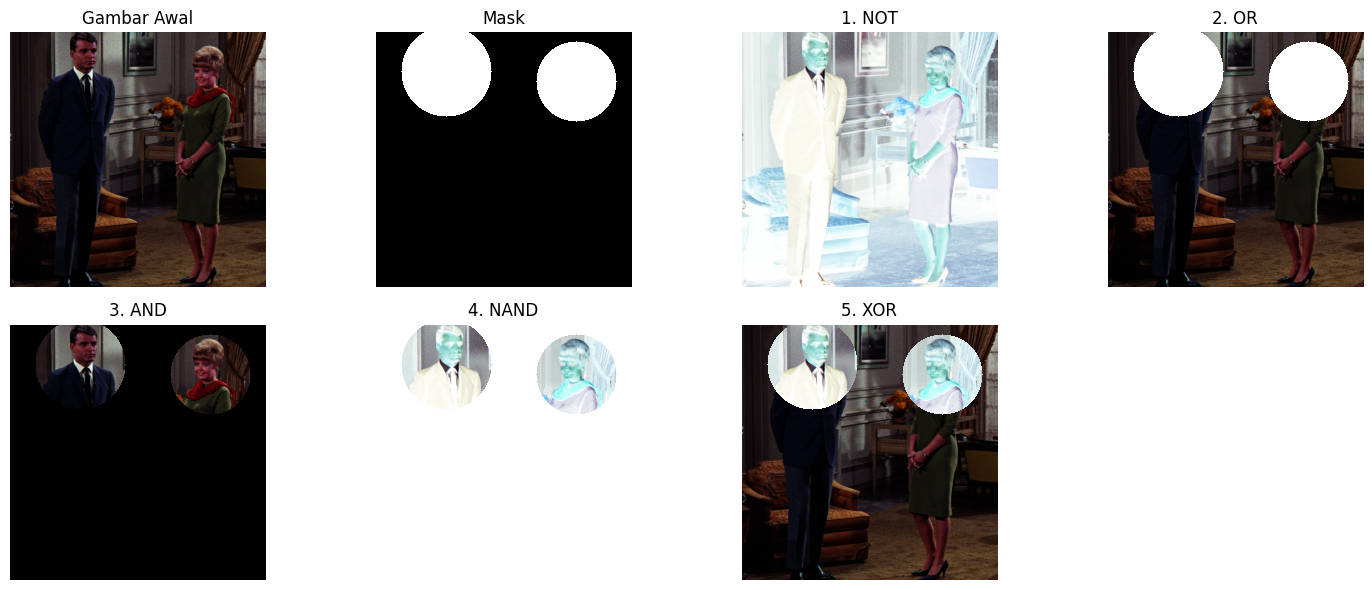

In [62]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/PCVK/Images/couple.tiff')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

mask = np.zeros(img.shape[:2], dtype=np.uint8)
cv.circle(mask, (70, 40), 45, (255), -1)
cv.circle(mask, (200, 50), 40, (255), -1)

mask_3ch = cv.merge([mask, mask, mask])

img_not = cv.bitwise_not(img_rgb)
img_or = cv.bitwise_or(img_rgb, mask_3ch)
img_and = cv.bitwise_and(img_rgb, mask_3ch)
img_nand = cv.bitwise_not(img_and)
img_xor = cv.bitwise_xor(img_rgb, mask_3ch)

titles = ['Gambar Awal', 'Mask', '1. NOT', '2. OR', '3. AND', '4. NAND', '5. XOR']
images = [img_rgb, mask_3ch, img_not, img_or, img_and, img_nand, img_xor]

plt.figure(figsize=(15, 6))
for i in range(7):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

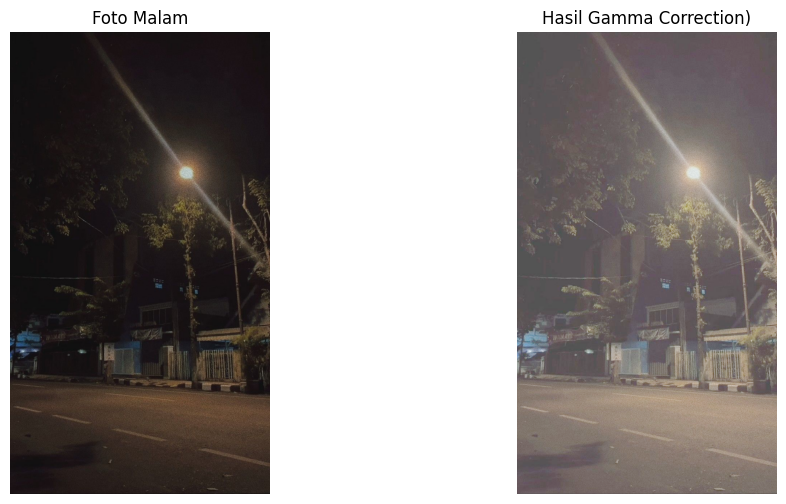

In [64]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/PCVK/malam.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

gamma = 0.4

gamma_image = 255.0 * (img_rgb / 255.0) ** gamma
gamma_image = np.clip(gamma_image, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_rgb)
ax[0].set_title('Foto Malam')
ax[0].axis('off')

ax[1].imshow(gamma_image)
ax[1].set_title(f'Hasil Gamma Correction)')
ax[1].axis('off')
plt.show()

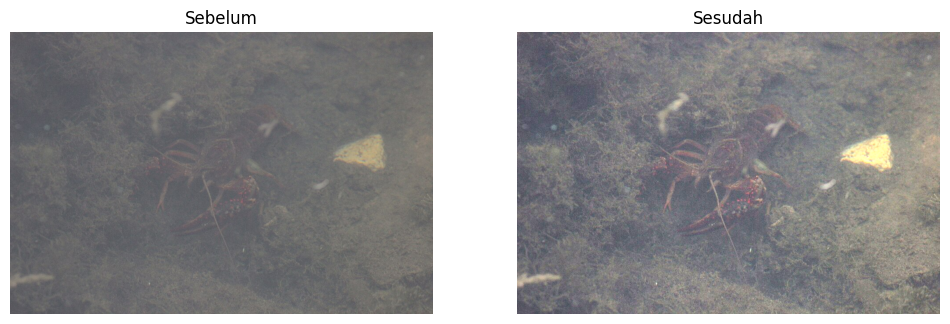

In [61]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/PCVK/Images/crayfish.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

alpha = 2.2
beta = -110

img_enhanced = np.clip(alpha * img_rgb.astype(np.float64) + beta, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_rgb)
ax[0].set_title('Sebelum')
ax[0].axis('off')

ax[1].imshow(img_enhanced)
ax[1].set_title(f'Sesudah')
ax[1].axis('off')
plt.show()